In [3]:
import pandas as pd
import numpy as np
import warnings 
import holidays
import matplotlib.pyplot as plt
import koreanize_matplotlib
warnings.filterwarnings('ignore')

In [4]:
# !pip install holidays

In [5]:
# !pip install xgboost

In [6]:
# !pip install lightgbm

In [7]:
target_station = ['ST-1035','ST-454','ST-471']

In [8]:
df2024 = pd.read_csv('../../Data/Zero/2024_data.csv')
df2025 = pd.read_csv('../../Data/Zero/2025_data.csv')

df = pd.concat([df2024,df2025],axis=0)
df = df.sort_values(['시작_대여소_ID','기준_날짜','시간대'])

df = df.iloc[:,[i for i in range(df.shape[1]) if i != 2]]
df


,기준_날짜,시간대,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량
27038,2025-04-04,21,ST-10,ST-454,1.0,3300,9035.0,7.3,71,47.19117,0.0,0.0
27055,2025-04-04,21,ST-10,ST-454,1.0,3300,9035.0,7.3,71,47.19117,0.0,0.0
40169,2025-04-29,21,ST-10,ST-454,1.0,3180,8630.0,10.9,62,52.95342,0.0,0.0
40185,2025-04-29,21,ST-10,ST-454,1.0,3180,8630.0,10.9,62,52.95342,0.0,0.0
46014,2025-05-11,22,ST-10,ST-454,1.0,3480,9047.0,11.5,93,52.90405,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
70218,2025-06-18,18,ST-991,ST-454,1.0,2940,7052.0,26.5,51,73.85185,0.0,0.0
22146,2025-03-25,17,ST-992,ST-454,1.0,3780,14144.0,12.9,54,55.92334,0.0,0.0
22160,2025-03-25,17,ST-992,ST-454,1.0,3780,14144.0,12.9,54,55.92334,0.0,0.0
155123,2025-12-12,13,ST-997,ST-454,2.0,9360,26487.0,4.8,37,46.65524,0.0,0.0


In [9]:

df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])

# 요일
df['weekday'] = df['기준_날짜'].dt.dayofweek

# 평일 / 주말
df['day_type'] = np.where(df['weekday'] < 5, 0, 1)

# feature
features = [
    '시간대',
    'day_type',
    '온도',
    '습도',
    '불쾌지수',
    '강수량',
    '적설량'
]

target = '전체_건수'

==================== 
Train Test

In [10]:
train = df[df['기준_날짜'].dt.year == 2024]
test  = df[df['기준_날짜'].dt.year == 2025]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

================ RandomForest 

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, pred_rf))

RF MAE: 0.09000958524054642


============
XGBoost

In [12]:
# from xgboost import XGBRegressor

# xgb = XGBRegressor(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=8,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42
# )

# xgb.fit(X_train, y_train)

# pred_xgb = xgb.predict(X_test)

# print("XGB MAE:", mean_absolute_error(y_test, pred_xgb))

In [13]:
# !pip uninstall -y xgboost
# !conda remove -y xgboost libomp llvm-openmp
# !conda install -c conda-forge libomp xgboost

===================
lightgbm

In [14]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

pred_lgb = lgb_model.predict(X_test)

print("LGB MAE:", mean_absolute_error(y_test, pred_lgb))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004060 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 700
[LightGBM] [Info] Number of data points in the train set: 187117, number of used features: 7
[LightGBM] [Info] Start training from score 1.049466
LGB MAE: 0.08948748852113733


In [15]:
from sklearn.metrics import mean_squared_error

def score(y_true, pred, name):

    mae = mean_absolute_error(y_true, pred)
    rmse = np.sqrt(mean_squared_error(y_true, pred))

    print(name)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print()

score(y_test, pred_rf, "RandomForest")
# score(y_test, pred_xgb, "XGBoost")
score(y_test, pred_lgb, "LightGBM")

RandomForest
MAE: 0.09000958524054642
RMSE: 0.2256558623269084

LightGBM
MAE: 0.08948748852113733
RMSE: 0.2256672763068574



=================

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("RF MAE:", mean_absolute_error(y_test, pred_rf))
print("RF RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("RF R2:", r2_score(y_test, pred_rf))

RF MAE: 0.08993393505803149
RF RMSE: 0.2256305428129294
RF R2: 0.005251876363807084


In [17]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42
)

hgb.fit(X_train, y_train)
pred_hgb = hgb.predict(X_test)

print("HGB MAE:", mean_absolute_error(y_test, pred_hgb))
print("HGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_hgb)))
print("HGB R2:", r2_score(y_test, pred_hgb))

HGB MAE: 0.08928041987520254
HGB RMSE: 0.2255155739054084
HGB R2: 0.00626535589123034


In [18]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(X_train, y_train)
pred_lgb = lgb_model.predict(X_test)

print("LGB MAE:", mean_absolute_error(y_test, pred_lgb))
print("LGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_lgb)))
print("LGB R2:", r2_score(y_test, pred_lgb))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003716 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 700
[LightGBM] [Info] Number of data points in the train set: 187117, number of used features: 7
[LightGBM] [Info] Start training from score 1.049466
LGB MAE: 0.08948748852113733
LGB RMSE: 0.2256672763068574
LGB R2: 0.00492795258846368


In [19]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

print("Ridge MAE:", mean_absolute_error(y_test, pred_ridge))
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, pred_ridge)))
print("Ridge R2:", r2_score(y_test, pred_ridge))

Ridge MAE: 0.09071801694401348
Ridge RMSE: 0.22577598500266527
Ridge R2: 0.003969027210482756


In [20]:
from sklearn.linear_model import ElasticNet

enet = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
enet.fit(X_train, y_train)
pred_enet = enet.predict(X_test)

print("ElasticNet MAE:", mean_absolute_error(y_test, pred_enet))
print("ElasticNet RMSE:", np.sqrt(mean_squared_error(y_test, pred_enet)))
print("ElasticNet R2:", r2_score(y_test, pred_enet))

ElasticNet MAE: 0.09122487019489064
ElasticNet RMSE: 0.22617350444674658
ElasticNet R2: 0.0004585542782618024


In [21]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

svr = make_pipeline(
    StandardScaler(),
    SVR(C=10, epsilon=0.1, kernel='rbf')
)

svr.fit(X_train, y_train)
pred_svr = svr.predict(X_test)

print("SVR MAE:", mean_absolute_error(y_test, pred_svr))
print("SVR RMSE:", np.sqrt(mean_squared_error(y_test, pred_svr)))
print("SVR R2:", r2_score(y_test, pred_svr))

SVR MAE: 0.13702639099321598
SVR RMSE: 0.23261699844827954
SVR R2: -0.0573049058162487


In [22]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

models = {
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=300,
        max_depth=8,
        min_samples_leaf=20,
        random_state=42
    ),
    "Ridge": Ridge(alpha=1.0),
    "SVR": make_pipeline(
        StandardScaler(),
        SVR(C=10, epsilon=0.1, kernel='rbf')
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values("MAE")
print(results_df)

                  model       MAE      RMSE        R2
1  HistGradientBoosting  0.089280  0.225516  0.006265
0          RandomForest  0.089934  0.225631  0.005252
2                 Ridge  0.090718  0.225776  0.003969
3                   SVR  0.137026  0.232617 -0.057305


=======================

In [31]:
df['lag1'] = df['전체_건수'].shift(1)
df['lag3'] = df['전체_건수'].shift(3)
df['lag24'] = df['전체_건수'].shift(24)
df['hour_sin'] = np.sin(2*np.pi*df['시간대']/24)
df['hour_cos'] = np.cos(2*np.pi*df['시간대']/24)
df['rolling3'] = df['전체_건수'].rolling(3).mean()
df['rolling24'] = df['전체_건수'].rolling(24).mean()

In [32]:
features = [
    '시간대',
    'day_type',
    '온도',
    '습도',
    '불쾌지수',
    '강수량',
    '적설량',
    'lag1',
    'lag3',
    'lag24',
    'hour_sin',
    'hour_cos',
    'rolling3',
    'rolling24'
]

train = df[df['기준_날짜'].dt.year == 2024]
test  = df[df['기준_날짜'].dt.year == 2025]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

In [33]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42
)

hgb.fit(X_train, y_train)
pred_hgb = hgb.predict(X_test)

print("HGB MAE:", mean_absolute_error(y_test, pred_hgb))
print("HGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_hgb)))
print("HGB R2:", r2_score(y_test, pred_hgb))

HGB MAE: 0.04017659360847339
HGB RMSE: 0.15026820730857515
HGB R2: 0.5587836852480726


In [34]:
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=42
)

lgb_model.fit(X_train, y_train)
pred_lgb = lgb_model.predict(X_test)

print("LGB MAE:", mean_absolute_error(y_test, pred_lgb))
print("LGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_lgb)))
print("LGB R2:", r2_score(y_test, pred_lgb))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006621 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 799
[LightGBM] [Info] Number of data points in the train set: 187117, number of used features: 14
[LightGBM] [Info] Start training from score 1.049466
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

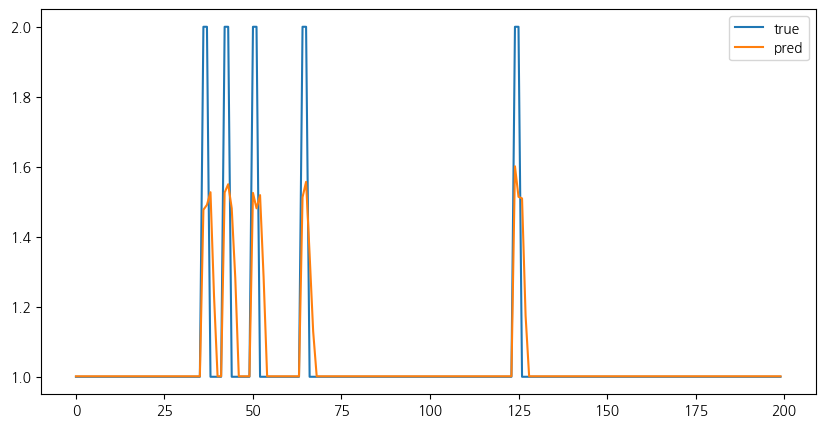

In [35]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:200], label='true')
plt.plot(pred_hgb[:200], label='pred')

plt.legend()
plt.show()

===========================

In [37]:
df['lag48'] = df['전체_건수'].shift(48)
df['lag168'] = df['전체_건수'].shift(168)
df['dow'] = df['기준_날짜'].dt.dayofweek
df['rush_hour'] = ((df['시간대']>=7)&(df['시간대']<=9)) | ((df['시간대']>=17)&(df['시간대']<=19))
df['rush_hour'] = df['rush_hour'].astype(int)
features = [
    '시간대',
    'day_type',
    '온도',
    '습도',
    '불쾌지수',
    '강수량',
    '적설량',
    'lag1',
    'lag3',
    'lag24',
    'hour_sin',
    'hour_cos',
    'rolling3',
    'rolling24',
    'lag48',
    'lag168',
    'dow',
    'rush_hour'
]

train = df[df['기준_날짜'].dt.year == 2024]
test  = df[df['기준_날짜'].dt.year == 2025]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

from sklearn.ensemble import HistGradientBoostingRegressor

hgb = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=600,
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

hgb.fit(X_train, y_train)
pred_hgb = hgb.predict(X_test)

print("HGB MAE:", mean_absolute_error(y_test, pred_hgb))
print("HGB RMSE:", np.sqrt(mean_squared_error(y_test, pred_hgb)))
print("HGB R2:", r2_score(y_test, pred_hgb))

HGB MAE: 0.04102439294063508
HGB RMSE: 0.15052098496367836
HGB R2: 0.5572980292507594
